# Radio Data Analysis for ECLEs

In [1]:
import otter
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from astropy import units as u
from astropy.cosmology import Planck18 as cosmo

### Luminosity vs. time plot of all of the ECLEs

In [3]:
db = otter.Otter('.otter')

ecles = pd.read_csv('ecle-meta-data.csv')

ecle_radio_phot = db.get_phot(names=ecles.name.tolist(), flux_unit='mJy', freq_unit='GHz', return_type='pandas', obs_type='radio')
all_radio_phot = db.get_phot(flux_unit='mJy', freq_unit='GHz', return_type='pandas', obs_type='radio')

other_radio_phot = all_radio_phot[~all_radio_phot.name.isin(ecle_radio_phot.name)]

other_radio_phot = other_radio_phot[other_radio_phot.filter_name == 'S']
ecle_radio_phot = ecle_radio_phot[ecle_radio_phot.filter_name == 'S']

===
Unable to establish connection, perhaps arango is not running.
===


MissingSchema: Invalid URL '.otter/_api/user/user-guest/database': No scheme supplied. Perhaps you meant https://.otter/_api/user/user-guest/database?

In [ ]:
def flux_to_lum(df):
    res = []
    for name, grp in df.groupby('name'):
        t = db.get_meta(names=name)[0]
        z = float(t.get_redshift())
        lum_dist = cosmo.luminosity_distance(z)
        flux = (grp.converted_flux*grp.converted_freq).values*u.GHz*u.mJy
        lum = (4*np.pi*lum_dist**2*(flux)).cgs.value
        grp['lum'] = lum
        grp['lum_err'] = grp.lum * grp.converted_flux_err/grp.converted_flux
        res.append(grp)
    return pd.concat(res)

NameError: name 'flux_to_lum' is not defined

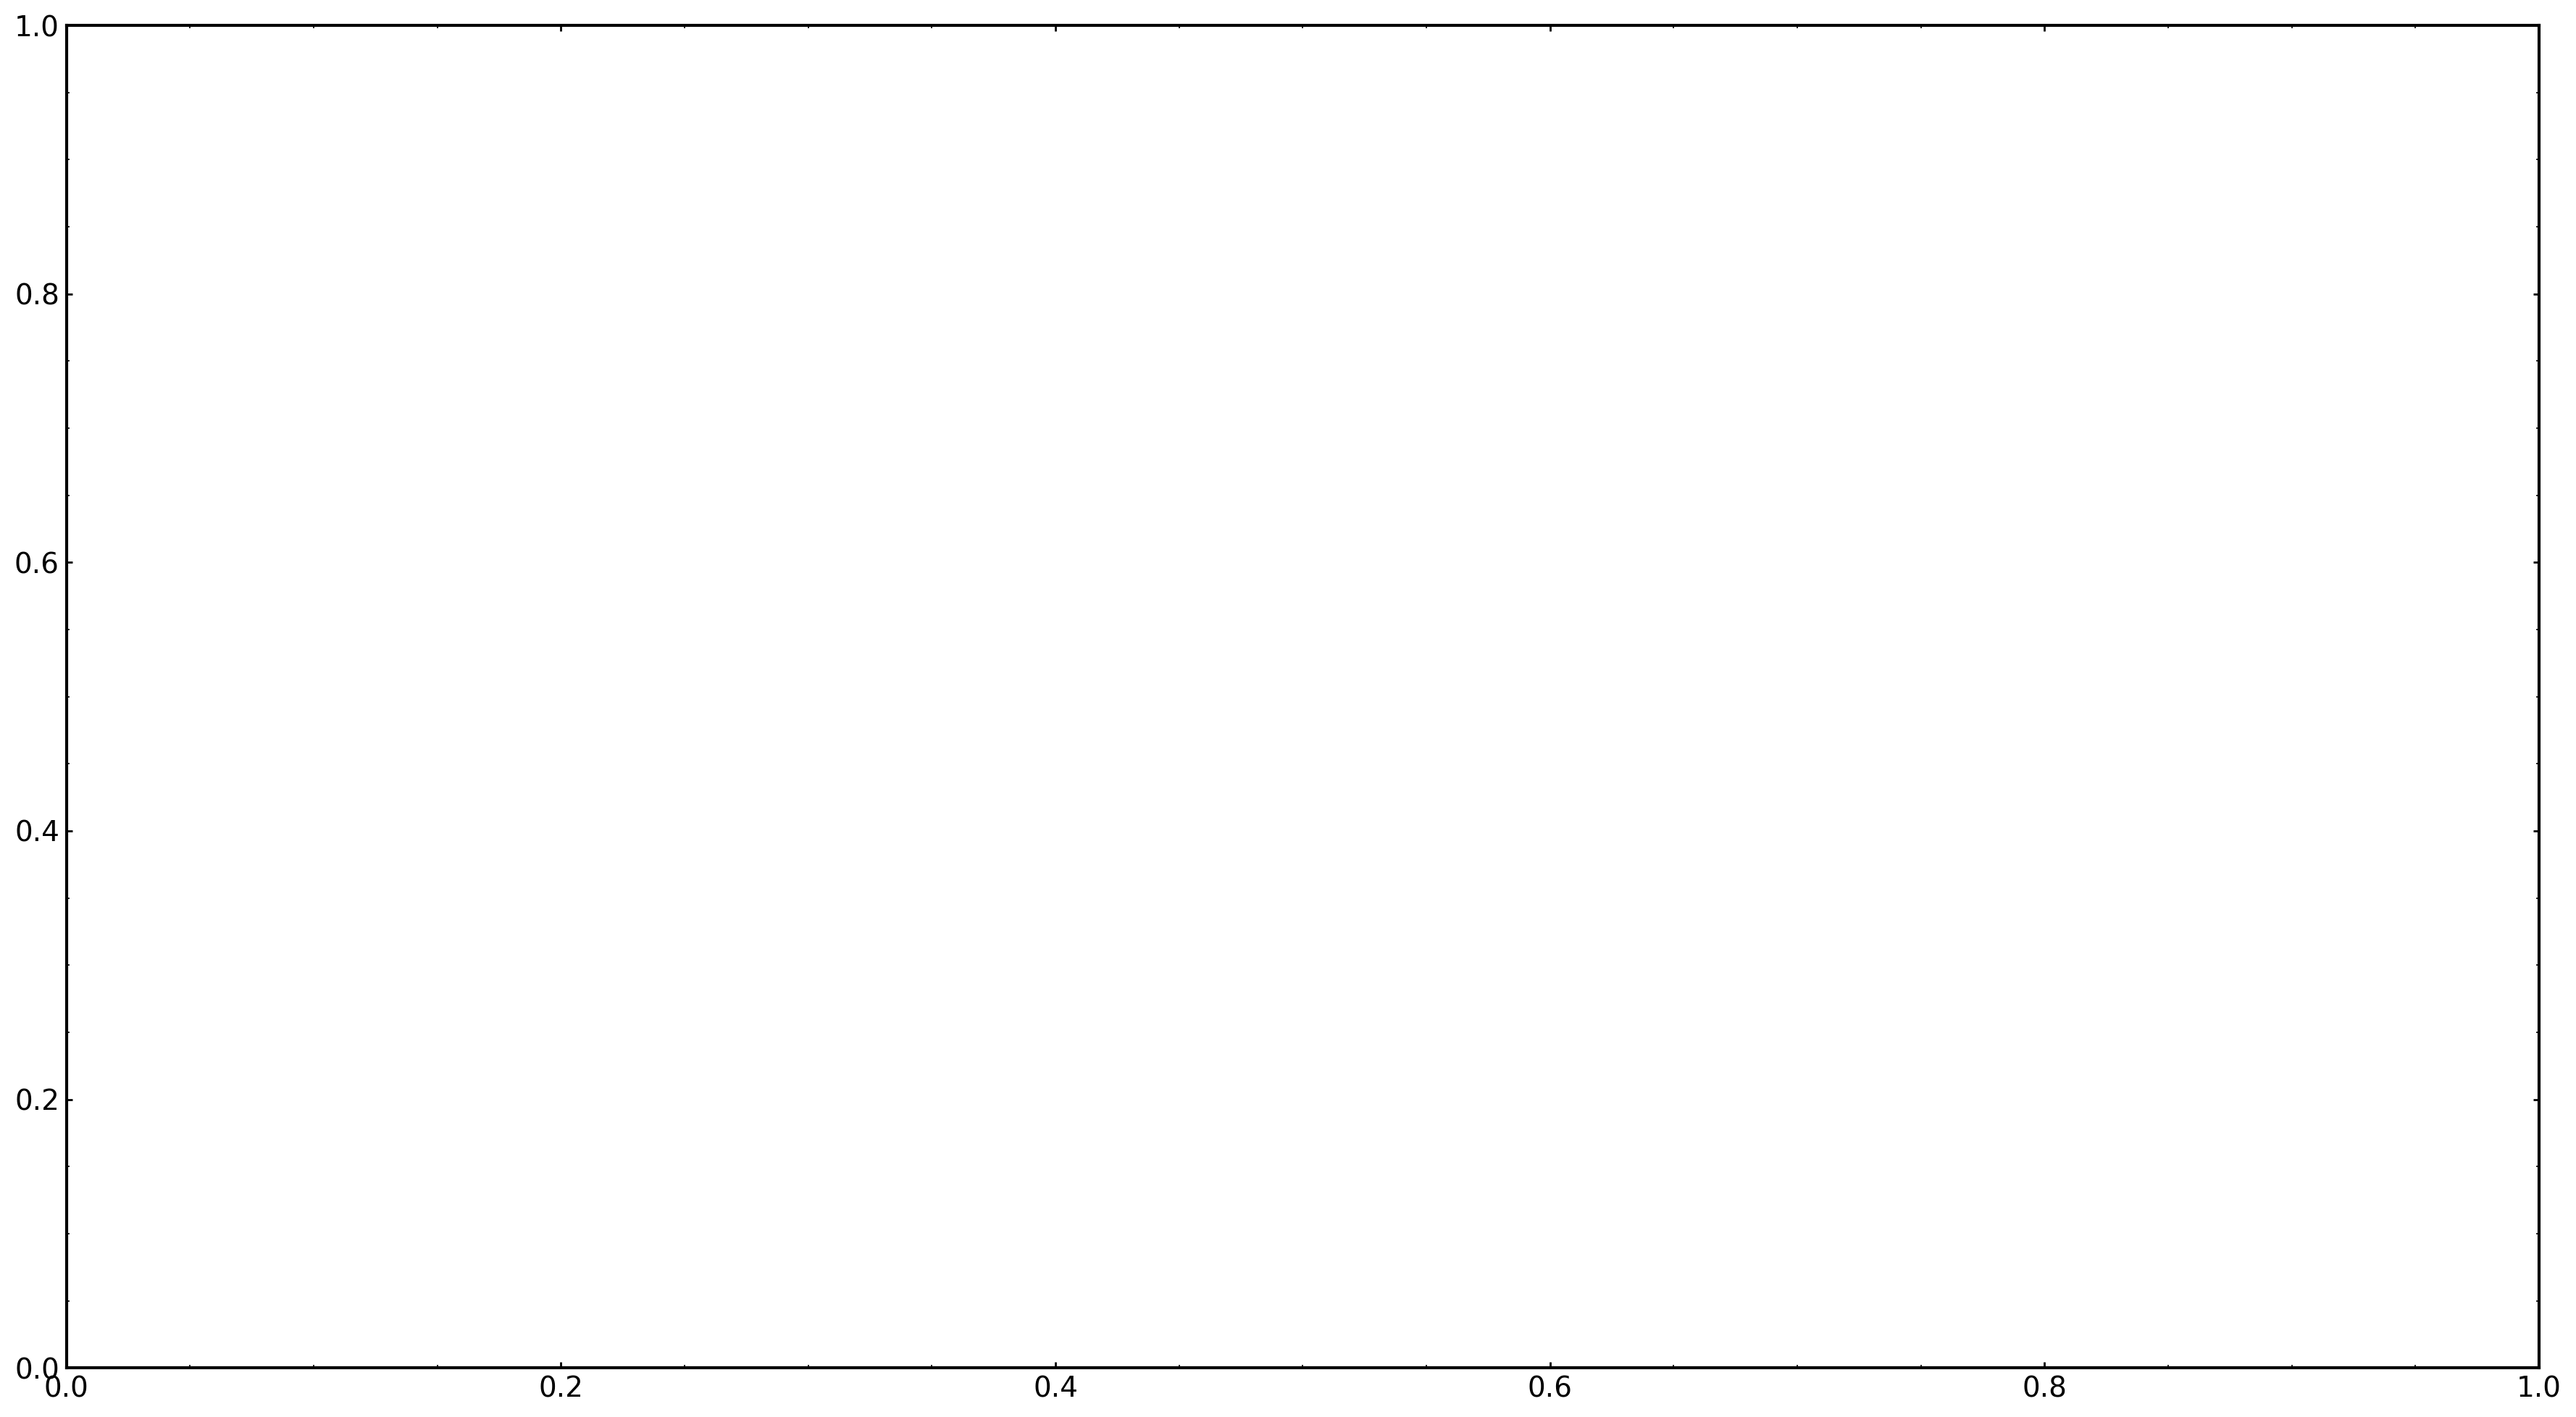

In [3]:
fig, ax = plt.subplots(figsize=(18,10))

other_radio_phot = flux_to_lum(other_radio_phot)
ecle_radio_phot = flux_to_lum(ecle_radio_phot)

cts = other_radio_phot.groupby('name').count()['lum']
other_names_plot = cts[cts > 5].index
grey_lc = other_radio_phot[other_radio_phot.name.isin(other_names_plot)]

for name, grp in grey_lc.groupby('name'):
    date_sorted = grp.converted_date.sort_values()
    x = date_sorted - date_sorted.iloc[0] + 1
    i = date_sorted.index
    
    ax.errorbar(x, grp.lum[i], yerr=grp.lum_err[i], color='grey', alpha=0.25, marker='o')


cmap = mpl.colormaps['inferno']    
colors = cmap(np.linspace(0, 1, len(ecle_radio_phot.name.unique())))

for (name, grp), col in zip(ecle_radio_phot.groupby('name'), colors):
    date_sorted = grp.converted_date.sort_values()
    x = date_sorted - date_sorted.values[0] + 1
    i = date_sorted.index

    classes = db.query(names=name)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']
    lab = f'{name.replace("_","")} ({ecle_class})'
    
    ax.errorbar(x, grp.lum[i], yerr=grp.lum_err[i], uplims=grp.upperlimit[i], marker='o', color=col, label=lab)
    
ax.set_yscale('log')
# ax.set_xscale('log')

ax.set_ylabel(r'Luminosity [$erg~s^{-1}$]')
ax.set_xlabel(r'$\Delta t$ Since First Observation [days]')

ax.legend(fontsize=10, bbox_to_anchor=(1.15,1));